## Physical simulation of gravity

This is theory notebook 1/5. You're in the right place to start.

This notebook explains the theory behind implementing a simulation of the physics of gravity between a chosen amount of objects. Note, however, that the principles explained here could be applied to any type of force.

The goal is to take a system of objects, with given initial conditions, and to calculate how it changes over time. We can see this change by looking at quantities such as the positions of the objects or the energy in the system.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

To start, let us take a look at the relevant force in this simulation, namely gravity. We will be using the Newtonian formulation which you are likely familiar with. This is a force between any two objects with mass, which grows weaker as these objects are moved apart. Specifically, the equation describing the force that object $j$ applies to object $i$ (so $i$ would start moving) at positions $\vec{r}_i$ and $\vec{r}_j$ with masses $m_i$ and $m_j$ is given by

\begin{equation}
\nonumber
    \vec{F}_{ij} = -G \: \frac{m_i m_j}{r_{ij}^2} \: \hat{r}_{ij},
\end{equation}

where $G$ is Newton's constant, $r_{ij} = |\vec{r}_i - \vec{r}_j|$ is the distance between the two objects, and $\hat{r}_{ij} = \frac{\vec{r}_i - \vec{r}_j}{r_{ij}}$ is the unit vector pointing from one object to the other, ensuring that (in combination with the minus sign) the force pulls them towards each other. Also, note that $\vec{F}_{ij} = -\vec{F}_{ji}$ : the force of $i$ on $j$ has the same magnitude but is in the opposite direction, as Newton's third law dictates.

Implementing this force is fairly straightforward; we write a function that calculates it given the masses and positions of the objects. There is however one thing to account for: objects can move arbitrarily close to each other in this simulation, because we will not implement any radii or collision mechanics. This can cause problems, because for very small distances, the force becomes very large, causing ridiculously high velocities. Objects moving close to each other would then shoot off into the distance after passing through each other, which is a bit too unrealistic. To deal with this, we will implement a "minimal distance" that the simulation uses between two objects even if they get closer than that. This way they will still end up moving through each other, but the force will be more modest such that they are not catapulted into infinite distances. Note that doing this is not very realistic either, and the specific value of the minimal value is also just a choice; for situations where it is important that objects collide, this simulation is not well-suited.

One note is that we will set the value of Newton's constant to 1, instead of its SI-value of $6.674\cdot10^{-11} \: \mathrm{kg}^{-1} \mathrm{m}^3 \mathrm{s}^{-2}$. By doing this, we will work in a more "natural" system of units, which is easier to work with. We also won't be writing masses in kilograms etc.; effectively we ignore real-world units to make our numerical inputs simpler. It is fine to do this, because it does not matter whatsoever for the simulation. You only need to worry about units if you wish to apply this simulation to real-world situations, but if so it is easy enough set $G$ to its proper value and input other quantities in their proper units as well.

In [2]:
G = 1
minimal_distance = 0.05  # to avoid infinities

def gravity_force(m_i, m_j, r_i, r_j):
    """
    Calculate the gravitational force exerted on object i by object j.
    Parameters:
        - m_i (float): Mass of object i
        - m_j (float): Mass of object j
        - r_i (np.array): Position vector of object i
        - r_j (np.array): Position vector of object j
    """
    r_ij = r_i - r_j
    distance = np.linalg.norm(r_ij)
    if distance < minimal_distance:
        distance = minimal_distance
    unit_r_ij = r_ij / distance
    return -G * m_i * m_j / distance**2 * unit_r_ij

With our driving force defined, we consider the working of the simulation itself. We want to figure out how the objects move under the influence of the forces. The main recipe for this is fairly simple:

1. Calculate all the forces that act on a given object.
2. Calculate the acceleration of the object due to these forces.
3. Calculate the change in velocity due to the acceleration of the object.
4. Calculate the change in position due to the velocity and acceleration of the object.

This is applied at every timestep $dt$ we take in our simulation. The different quantities are evaluated after these each of these steps. In order to get an accurate result, the steps should be small, so that the system can react to changes quickly. Additionally, we define the total number of timestep we will take in the simulation. The product of the timestep and number of steps then determines how long the simulation will run (in our internal natural units).

In [3]:
dt = 1e-4  # timestep
N_steps = 10000

Let's then look at the equations that allow us to calculate these quantities.
The net resulting force on object $i$ at time $t$ due to all other objects is the sum of the forces exerted by the other objects and can be written as

\begin{equation}
\nonumber
    \vec{F}_i (t) = \sum_{j=1, \: j \neq i}^\mathrm{N_{objects}} \vec{F}_{ij} (t).
\end{equation}

The resulting acceleration on object $i$ is found using Newton's second law:
\begin{equation}
\nonumber
    \vec{a}_i (t) = \vec{F}_i (t) / m_i.
\end{equation}

To then find the change in velocity and position, we use the so-called Verlet integration method (see e.g. Wikipedia https://en.wikipedia.org/wiki/Verlet_integration). This is a bit more complicated than so-called Euler integration, but it properly conserves energy and momentum and shows explicit time reversibility, which is important in physics. 

While we can simply calculate the force and acceleration at any timestep based on the system at that time, the velocity and position also depend on their values at the previous timestep, and in the Verlet algorithm additionally on the acceleration at the current and previous timestep.
The velocity at the next timestep $t+dt$ is then given by

\begin{equation}
\nonumber
    \vec{v}_i (t+dt) = \vec{v}_i(t) + \frac{dt}{2} \left( \vec{a}_i (t+dt) + \vec{a}_i (t) \right),
\end{equation}

and the position by

\begin{equation}
\nonumber
    \vec{r}_i (t+dt) = 2 \vec{r}_i(t) - \vec{r}_i(t-dt) + \vec{a}_i (t) dt^2.
\end{equation}

Note that we thus need the previous _two_ positions of an object to find its current position.

In [4]:
def next_velocity(current_velocity, next_acceleration, current_acceleration):
    """
    Find the velocity at the next timestep using the Verlet integration method.
    Parameters:
        - current_velocity (np.array): Velocity at the current timestep
        - next_acceleration (np.array): Acceleration at the next timestep
        - current_acceleration (np.array): Acceleration at the current timestep
    """
    return current_velocity + 0.5 * dt * (next_acceleration + current_acceleration)

def next_position(current_position, previous_position, current_acceleration):
    """
    Find the position at the next timestep using the Verlet integration method.
    Parameters:
        - current_position (np.array): Position at the current timestep
        - previous_position (np.array): Position at the previous timestep
        - current_acceleration (np.array): Acceleration at the current timestep
    """
    return 2 * current_position - previous_position + current_acceleration * dt**2

In order to start the simulation, we then finally need initial conditions, that specify the state of the system at the beginning. So not only how many objects we have and their masses, but also their initial positions and velocities. We are free to choose these however we like. For this script, we will consider three objects that are aligned on the $y$-axis. The middle one is much heavier than the other two and is stationary, while the other two have opposing velocities in the $x$-direction. Nothing will happen in the $z$-direction, as this is harder to visualize, but the code is written such that this can be added.

One thing to keep in mind is that we need the previous _two_ positions to find an objects current position, but we have now only defined one starting position. In order to get the second positions, we thus have to use a different equation. Here we can apply the (simpler) Euler integration, which won't cause any trouble as it is only applied once. This is given by

\begin{equation}
\nonumber
    \vec{r}_i (0+dt) = \vec{r}_i(0) + \vec{v}_i(0) dt + \frac{1}{2} \vec{a}_i (0) dt^2.
\end{equation}

In [5]:
N_objects = 3

# Make an array with the mass of each object
masses = np.array([100, 1, 1])

# Make an array 'positions' to mark the positions of the objects
# Here positions[i] are the positions of all objects at timestep i,
# positions[i][j] is the position of object j at timestep i,
# positions[i][j][k] is the k-coordinate of object j at timestep i.
positions = np.zeros(shape=[N_steps, N_objects, 3])  # 3 for x, y, z coordinates

# Choose initial positions
positions[0][0] = np.array([0,0,0])
positions[0][1] = np.array([0,1,0])
positions[0][2] = np.array([0,-1,0])

# Make an array 'velocities' to mark the velocities of the objects
# with the same structure as positions
velocities = np.zeros(shape=[N_steps, N_objects, 3])

# Choose initial velocities
velocities[0][0] = np.array([0,0,0])
velocities[0][1] = np.array([5,0,0])
velocities[0][2] = np.array([-5,0,0])

# Also need to keep the previous acceleration for velocity
# Note we don't save these for all timesteps, only the previous one
previous_accelerations = np.zeros(shape=[N_objects, 3])

# Use Euler integration to find the positions at the second timestep
for j in range(N_objects):
    force = np.zeros(3)  # to add up all forces on object j
    for k in range(N_objects):
        # Consider all other objects k, so without k==j
        if k != j:
            force += gravity_force(masses[j], masses[k], positions[0][j], positions[0][k])
    acceleration = force / masses[j]
    previous_accelerations[j] = acceleration  # update these to contain step 0 accelerations

    # Now update positions with Euler
    positions[1][j] = positions[0][j] + velocities[0][j] * dt + 0.5 * acceleration * dt**2

# With the new positions of all the particles, calculate the acceleration at step 1
for j in range(N_objects):
    force = np.zeros(3)  # to add up all forces on object j
    for k in range(N_objects):
        # Consider all other objects k, so without k==j
        if k != j:
            force += gravity_force(masses[j], masses[k], positions[1][j], positions[1][k])
    acceleration = force / masses[j]

    # Now update velocities with Verlet
    velocities[1][j] = next_velocity(velocities[0][j], acceleration, previous_accelerations[j])

    # And update the previous acceleration for the next loop
    previous_accelerations[j] = acceleration

Now we can run the simulation itself by looping through all remaining timesteps.

In [6]:
for i in range(2, N_steps):  # 0 set by initial conditions, 1 set by Euler
    for j in range(N_objects):
        # Update positions, with the already calculated previous acceleration
        positions[i][j] = next_position(positions[i-1][j], positions[i-2][j], previous_accelerations[j])
    
    # Once all positions are updated, calculate new accelerations and update velocities
    for j in range(N_objects):
        force = np.zeros(3)  # to add up all forces on object j
        for k in range(N_objects):
            # Consider all other objects k, so without k==j
            if k != j:
                force += gravity_force(masses[j], masses[k], positions[i][j], positions[i][k])
        acceleration = force / masses[j]

        # So update velocities
        velocities[i][j] = next_velocity(velocities[i-1][j], acceleration, previous_accelerations[j])
        # And update the previous acceleration for the next loop
        previous_accelerations[j] = acceleration

Let's look at the result by plotting the trajectories.

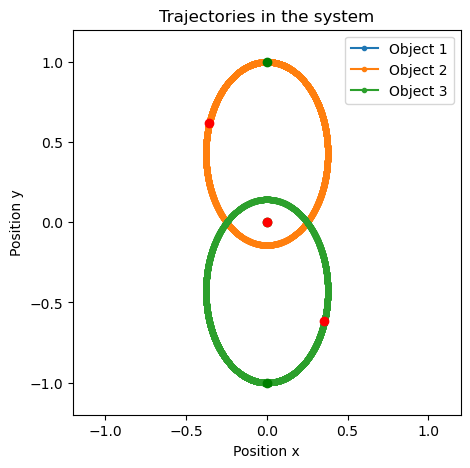

In [7]:
plt.figure(figsize=(5,5))
for i in range(N_objects):
    obj_i_positions = positions[:,i,:]
    plt.plot(obj_i_positions[:,0], obj_i_positions[:,1], marker='.', label=f'Object {i+1}')
    # Object starts at green dot, ends at red dot
    plt.plot(obj_i_positions[0,0], obj_i_positions[0,1], marker='.', color='green', markersize=12)
    plt.plot(obj_i_positions[-1,0], obj_i_positions[-1,1], marker='.', color='red', markersize=12)

plt.xlabel('Position x')
plt.ylabel('Position y')
plt.title('Trajectories in the system')
plt.legend()
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.show()

We see that the resulting trajectories seem pretty reasonable. The central object remains stationary, as one would expect since it experiences equal forces in opposite directions due to the other two objects. The lighter objects make elliptical orbits around the central one. We can actually calculate the speed that is necessary for circular motion around the massive central object with mass $M$ as $v = \sqrt{GM/r}$, which for our chosen values gives $v=10$. (If you run the simulation with this initial speed, you can see the orbits indeed form fairly nice circles.) So for our pick of a lower initial speed, we expect ellipses to form, as is indeed the case here. For higher speeds we expect the objects to fly away to infinity, which you can check also happens in the simulation.

Another way to check if the simulation works properly is by looking at the energy of the system at each timestep, as this should remain constant. There are two types of energies in this gravitational simulation. Firstly, there is the kinetic energy of each object, given by

\begin{equation}
\nonumber
    T_i(t) = \frac{1}{2} m_i |\vec{v}_i(t)|^2.
\end{equation}

Secondly, there is the gravitational potential energy between each pair of objects (just like the force), so the potential energy between object $i$ and object $j$, given by

\begin{equation}
\nonumber
    U_{ij}(t) = -G \frac{m_i m_j}{r_{ij}(t)}.
\end{equation}

The sum of these energies for all objects needs to be constant in time:

\begin{equation}
\nonumber
    E = \sum_{i=1}^\mathrm{N_{objects}} \left( T_i(t) + \sum_{j=2, \: j > i}^\mathrm{N_{objects}} U_{ij}(t) \right) = \mathrm{const.}
\end{equation}

Note here that we only sum over the second object in such a way that we avoid double counting: e.g. we don't want to count both $U_{12}$ and $U_{21}$ as they are the same, and this amount of energy only "exists once". By taking $j>i$, we ensure unique pairs. For the three objects in our example, we thus get the pairs 1-2, 1-3, 2-3 only.

In [8]:
times = np.arange(N_steps) * dt
# Get the kinetic energies from velocities
kinetic_per_particle = 0.5 * masses * np.sum(velocities**2, axis=2)
kinetic_total = np.sum(kinetic_per_particle, axis=1)

# Get the potential energies from positions
potential_total = np.zeros(shape=[N_steps])
for j in range(N_objects-1):  # don't need to consider the last object, is cancelled in next loop
    r_j = positions[:,j,:]
    for k in range(j+1, N_objects):  # start from the object after j
        r_k = positions[:,k,:]
        distance = np.linalg.norm(r_j - r_k, axis=1)  # distance between j and k at all timesteps

        # Filter distances to avoid infinities
        distance[ distance < minimal_distance ] = minimal_distance
        
        potential_jk = -G * masses[j] * masses[k] / distance
        potential_total += potential_jk

energy = kinetic_total + potential_total

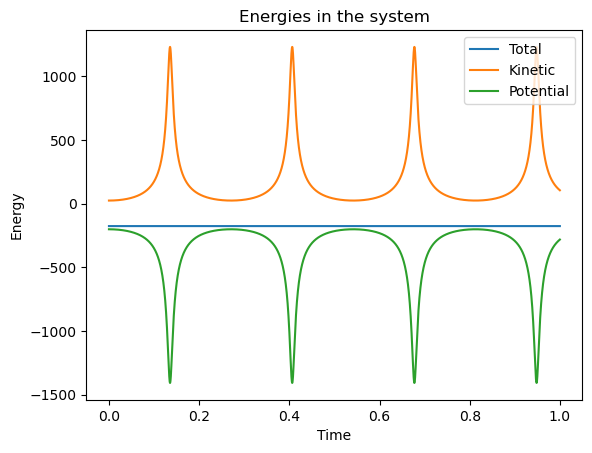

In [9]:
# Plot the different energies over time
plt.figure()
plt.plot(times, energy, label="Total")
plt.plot(times, kinetic_total, label="Kinetic")
plt.plot(times, potential_total, label="Potential")
plt.title("Energies in the system")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()
plt.show()

This plot also looks very reasonable. The kinetic and potential energy mirror each other: as the two outer objects are pulled towards the central one their increasing speeds increase the kinetic energy and the decreasing distance decreases the potential energy simultaneously. As the objects move away again on their ellipses the speed decreases and distance increases, with the energies following suit. This process repeats as the objects make multiple rounds. The total energy is very constant as it should. If we zoom in on the total energy we do see a small deviation every time the kinetic and potential energy peak; here they do not seem to cancel perfectly. The deviation is only about 0.05 though, negligible compared to the energies present in the system, so it doesn't seem to cause any issues.